The Feed Forward Neural Network

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
#Here we create our model, we say how the structure of the neural network looks like
class Model(nn.Module):

    def __init__(self, input_dim, hidden1, hidden2, dropout, out_features=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1) #in fully connected hidden layer 1 the input to this layer is the imput features, and output is hidden1
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, out_features)
        self.dropout = nn.Dropout(dropout) # regularization: randomly zero some activations during training

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.out(x)

        return x


Training the Model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
#importing the data
#Now loading three SEPARATE files: one for training, one for validation, one for testing.
#Update these paths to wherever you saved the three parquet files.

train_url = r"C:\Users\GESADIK\Downloads\03_2026_06_26\03\03_community_area_1h_train.parquet"
val_url   = r"C:\Users\GESADIK\Downloads\03_2026_06_26\03\03_community_area_1h_val.parquet"
test_url  = r"C:\Users\GESADIK\Downloads\03_2026_06_26\03\03_community_area_1h_test.parquet"

train_db = pd.read_parquet(train_url)
val_db   = pd.read_parquet(val_url)
test_db  = pd.read_parquet(test_url)


In [5]:
# Drop the same columns from the train, validation, and test sets,
# so all three end up with identical feature columns.

cols_to_drop = [
    'nature',
    'tourism',
    'public_services',
    'shops',
    'leisure',
    'amenity',
    'education',
    'healthcare',
    'temperature_min_c',
    'temperature_max_c',
    #'temperature_c',
    #'strong_wind',
    #'wind',
    #'snow',
    #'heavy_rain',
    #'rain',
    #'StateHoliday',
    #'CityHoliday',
    #'CorporateHoliday',
    #'BankHoliday',
    #'DayOfWeek_Wednesday',
    #'DayOfWeek_Tuesday',
    #'DayOfWeek_Thursday',
    #'DayOfWeek_Sunday',
    #'DayOfWeek_Saturday',
    #'DayOfWeek_Friday',
]

train_db = train_db.drop(columns=cols_to_drop)
val_db   = val_db.drop(columns=cols_to_drop)
test_db  = test_db.drop(columns=cols_to_drop)


In [6]:
train_cols = list(train_db.drop(columns=["trip_count"]).columns)
val_cols   = list(val_db.drop(columns=["trip_count"]).columns)
test_cols  = list(test_db.drop(columns=["trip_count"]).columns)

print('Train columns match val columns:',  train_cols == val_cols)
print('Train columns match test columns:', train_cols == test_cols)

train_db


Train columns match val columns: True
Train columns match test columns: True


,community_area,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,...,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c
0,37,1,0.000000e+00,1.0,0.500000,0.866025,0,0,0,0,...,1,1,1,1,0,0,0,0,1,0.412776
1,76,55,0.000000e+00,1.0,0.500000,0.866025,0,0,0,0,...,1,1,1,1,0,0,0,0,1,0.412776
2,24,22,0.000000e+00,1.0,0.500000,0.866025,0,0,0,0,...,1,1,1,1,0,0,0,0,1,0.412776
3,39,1,0.000000e+00,1.0,0.500000,0.866025,0,0,0,0,...,1,1,1,1,0,0,0,0,1,0.412776
4,5,1,0.000000e+00,1.0,0.500000,0.866025,0,0,0,0,...,1,1,1,1,0,0,0,0,1,0.412776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617258,6,40,1.224647e-16,-1.0,-0.866025,-0.500000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.854218
617259,4,4,1.224647e-16,-1.0,-0.866025,-0.500000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.854218
617260,14,1,1.224647e-16,-1.0,-0.866025,-0.500000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.854218
617261,21,3,1.224647e-16,-1.0,-0.866025,-0.500000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.854218


In [7]:
#Spliting the data into inputs and output -- done separately for each dataset
X_train_df = train_db.drop('trip_count', axis=1)
Y_train_df = train_db['trip_count']

X_val_df = val_db.drop('trip_count', axis=1)
Y_val_df = val_db['trip_count']

X_test_df = test_db.drop('trip_count', axis=1)
Y_test_df = test_db['trip_count']


In [8]:
#Converting the tables into numpy arrays
X_train = X_train_df.values
Y_train = Y_train_df.values

X_val = X_val_df.values
Y_val = Y_val_df.values

X_test = X_test_df.values
Y_test = Y_test_df.values


In [ ]:
#train_test_split is no longer needed: train, validation, and test each come
#from their own file now, so there's nothing left to split here.


In [9]:
print(f'Train: {X_train.shape[0]} rows | Validation: {X_val.shape[0]} rows | Test: {X_test.shape[0]} rows')


Train: 617263 rows | Validation: 132270 rows | Test: 132270 rows


In [10]:
X_train = torch.FloatTensor(X_train)
X_val   = torch.FloatTensor(X_val)
X_test  = torch.FloatTensor(X_test)

Y_train = torch.FloatTensor(Y_train)
Y_val   = torch.FloatTensor(Y_val)
Y_test  = torch.FloatTensor(Y_test)


C:\Users\GESADIK\AppData\Local\Temp\ipykernel_28024\346228459.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  Y_train = torch.FloatTensor(Y_train)


In [11]:
from torch.utils.data import TensorDataset, DataLoader

## Hyperparameter Tuning: Grid Search

We search over combinations of hyperparameters (hidden layer sizes, dropout, learning rate, weight decay, batch size) **before building the final model**, so the model we create is already configured with values that performed best on held-out data.

To keep this practical on large datasets, we:
- use the **validation set** loaded from its own file (`03_community_area_1h_val.parquet`) to score every candidate; the test set stays untouched until the very end,
- train each candidate for just a few epochs on a **subsample** of the training data (enough to rank candidates, not enough to fully converge),
- pick the combination with the lowest validation MAE, then build and train the real model with those settings.


In [12]:
from sklearn.model_selection import ParameterGrid
import time

# Validation set now comes from its own file (X_val/Y_val), so there's no need
# to carve it out of the training data anymore. The test set (X_test/Y_test)
# is still never touched during the search, so it stays a fair, unbiased final check.
print(f'Train: {X_train.shape[0]} rows | Validation: {X_val.shape[0]} rows | Test (held out): {X_test.shape[0]} rows')


Train: 617263 rows | Validation: 132270 rows | Test (held out): 132270 rows


In [14]:
# Running every combination on the full training set would take too long,
# so we search on a random subsample and only train the final model on the full data.
SEARCH_SAMPLE_SIZE = 70000   # rows used per candidate during the search
EPOCHS_PER_COMBO   = 3       # short training runs, just enough to rank candidates

torch.manual_seed(42)
sample_idx = torch.randperm(X_train.shape[0])[:SEARCH_SAMPLE_SIZE]
X_search, Y_search = X_train[sample_idx], Y_train[sample_idx]


In [15]:
# The hyperparameter grid to search over.
# Feel free to widen these lists for a more thorough (but slower) search.
param_grid = {
    'hidden1':      [32],
    'hidden2':      [8],
    'lr':           [0.01],
    'weight_decay': [1e-5],
    'dropout':      [0.0],
    'batch_size':   [64, 128],
}

grid = list(ParameterGrid(param_grid))
print(f'Total combinations to try: {len(grid)}')

Total combinations to try: 2


In [16]:
def train_and_evaluate(params, X_tr, Y_tr, X_val, Y_val, epochs=EPOCHS_PER_COMBO):
    """Train a fresh model with the given hyperparameters and return its validation MAE."""
    torch.manual_seed(0)  # same starting point for every candidate -> a fair comparison

    candidate = Model(
        input_dim=X_tr.shape[1],
        hidden1=params['hidden1'],
        hidden2=params['hidden2'],
        dropout=params['dropout'],
    )
    candidate_optimizer = torch.optim.Adam(
        candidate.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay'],
    )
    candidate_loss_fn = nn.L1Loss()

    search_dataset = TensorDataset(X_tr, Y_tr)
    search_loader  = DataLoader(search_dataset, batch_size=params['batch_size'], shuffle=True)

    candidate.train()
    for epoch in range(epochs):
        for X_batch, Y_batch in search_loader:
            Y_pred = candidate.forward(X_batch)
            error = candidate_loss_fn(Y_pred.squeeze(), Y_batch)

            candidate_optimizer.zero_grad()
            error.backward()
            candidate_optimizer.step()

    candidate.eval()
    with torch.no_grad():
        Y_val_pred = candidate.forward(X_val)
        val_loss = candidate_loss_fn(Y_val_pred.squeeze(), Y_val).item()

    return val_loss

In [17]:
results = []
start = time.time()

for i, params in enumerate(grid, 1):
    val_loss = train_and_evaluate(params, X_search, Y_search, X_val, Y_val)
    results.append({**params, 'val_loss': val_loss})

    if i % 5 == 0 or i == len(grid):
        elapsed = time.time() - start
        print(f'[{i}/{len(grid)}] val_loss={val_loss:.4f}  (elapsed: {elapsed:.0f}s)')

print(f'\nGrid search finished in {time.time() - start:.0f}s')

[2/2] val_loss=14.7460  (elapsed: 8s)

Grid search finished in 8s


In [18]:
results_df = pd.DataFrame(results).sort_values('val_loss').reset_index(drop=True)
results_df.head(10)

,batch_size,dropout,hidden1,hidden2,lr,weight_decay,val_loss
0,64,0.0,32,8,0.01,0.00001,14.063539
1,128,0.0,32,8,0.01,0.00001,14.746048


In [19]:
best_params = results_df.iloc[0].to_dict()

print('Best hyperparameters found:')
for k, v in best_params.items():
    if k != 'val_loss':
        print(f'  {k}: {v}')
print(f'  -> validation MAE: {best_params["val_loss"]:.4f}')

Best hyperparameters found:
  batch_size: 64.0
  dropout: 0.0
  hidden1: 32.0
  hidden2: 8.0
  lr: 0.01
  weight_decay: 1e-05
  -> validation MAE: 14.0635


## Create the Model with the Best Hyperparameters

Now that we know which hyperparameters work best, we create the actual model, loss, optimizer, and data loader using those values.

In [21]:
#torch.manual_seed(42) #Without a fixed seed, you'd get different starting weights every time you run the notebook, and your model could converge differently (or even fail to converge) from run to run.

In [20]:
model = Model(
    input_dim=X_train.shape[1],
    hidden1=int(best_params['hidden1']),
    hidden2=int(best_params['hidden2']),
    dropout=best_params['dropout'],
    out_features = 1,
) # creating an instance of the model, using the best hyperparameters found above

In [21]:
#Criteria of the model to measure the loss
loss = nn.L1Loss();

In [22]:
#Chooseing optimizer, using the best lr and weight_decay found by the grid search
optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])

In [23]:
#Creating batches, using the best batch size found by the grid search
# batch_size rows into RAM instead of the full dataset.

BATCH_SIZE = int(best_params['batch_size'])

train_dataset = TensorDataset(X_train, Y_train)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [24]:
# Train our model
epochs = 30
losses = []

for i in range(1, epochs + 1):
    epoch_loss = 0.0

    for X_batch, Y_batch in train_loader:       # iterate one batch at a time
        Y_pred = model.forward(X_batch).squeeze()  # forward pass on the batch; squeeze to match Y_batch's shape [batch]
        error  = loss(Y_pred, Y_batch)          # measure the error

        optimizer.zero_grad()                   # reset gradients
        error.backward()                        # back propagation
        optimizer.step()                        # update weights & biases

        epoch_loss += error.item()

    avg_loss = epoch_loss / len(train_loader)   # average loss across all batches
    losses.append(avg_loss)
    print(f'Epoch: {i}  |  Loss: {avg_loss:.4f}')


Epoch: 1  |  Loss: 12.1376
Epoch: 2  |  Loss: 10.8015
Epoch: 3  |  Loss: 10.6729
Epoch: 4  |  Loss: 10.6147
Epoch: 5  |  Loss: 10.5730
Epoch: 6  |  Loss: 10.5590
Epoch: 7  |  Loss: 10.5456
Epoch: 8  |  Loss: 10.4305
Epoch: 9  |  Loss: 10.3402
Epoch: 10  |  Loss: 10.3487
Epoch: 11  |  Loss: 10.3208
Epoch: 12  |  Loss: 10.3179
Epoch: 13  |  Loss: 10.2972
Epoch: 14  |  Loss: 10.3133
Epoch: 15  |  Loss: 10.2948
Epoch: 16  |  Loss: 10.2840
Epoch: 17  |  Loss: 10.2882
Epoch: 18  |  Loss: 10.2840
Epoch: 19  |  Loss: 10.2734
Epoch: 20  |  Loss: 10.2655
Epoch: 21  |  Loss: 10.2418
Epoch: 22  |  Loss: 10.2382
Epoch: 23  |  Loss: 10.2361
Epoch: 24  |  Loss: 10.2343
Epoch: 25  |  Loss: 10.2320
Epoch: 26  |  Loss: 10.2324
Epoch: 27  |  Loss: 10.2284
Epoch: 28  |  Loss: 10.2240
Epoch: 29  |  Loss: 10.2283
Epoch: 30  |  Loss: 10.2359


Text(0.5, 0, 'Epoch')

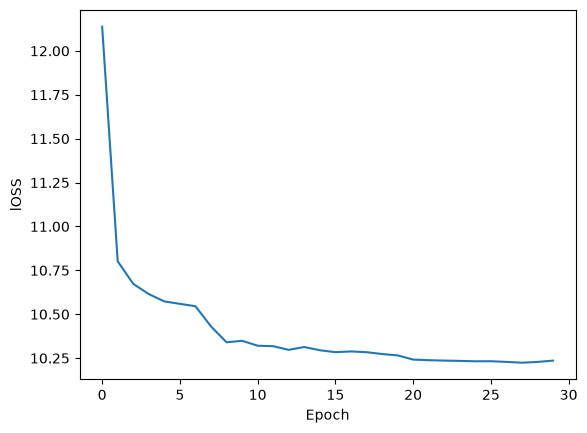

In [25]:
plt.plot(range(epochs), losses)
plt.ylabel('lOSS')
plt.xlabel('Epoch')

Evaluating the model with our test set

In [26]:
model.eval()  # turn off dropout for evaluation (was missing before - dropout was staying active at test time)
with torch.no_grad():  # turns off back propagation
    Y_eval = model.forward(X_test)

    Y_test = Y_test.view(-1, 1)   # Make shape [132270, 1]

    error = loss(Y_eval, Y_test)

print(error)


tensor(11.1568)


In [27]:
#checking how many we are getting correct
model.eval()
with torch.no_grad():
    Y_val_all = model.forward(X_test)                 # shape [N, 1], matches Y_test's shape after the reshape above
    correct = (torch.abs(Y_val_all - Y_test) < 1).sum().item()


In [28]:
print(f'Predictions correctness: {correct} / {len(X_test)} ({100*correct/len(X_test):.1f}%)')

Predictions correctness: 73434 / 132270 (55.5%)


Predicting using new data

In [37]:
#to translate the month sin and cos into a number

def sin_cos_to_month(month_sin, month_cos):
    # Recover angle
    angle = np.arctan2(month_sin, month_cos)

    # Convert negative angles to [0, 2π]
    if angle < 0:
        angle += 2 * np.pi

    # Convert angle back to month (1-12)
    month = round(angle * 12 / (2 * np.pi))

    # Handle wrap-around
    if month == 0:
        month = 12

    return month

# Example
month_sin = np.sin(2 * np.pi * 7 / 12)  # July
month_cos = np.cos(2 * np.pi * 7 / 12)

print(sin_cos_to_month(month_sin, month_cos))


7


In [ ]:
#new_data = torch.tensor([45, -0.7071, 0.7071, -0.866, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0.597, 0.558, 0.6423, 0.0288, 0.0689, 0.0125, 0.0336, 0.02898, 0.0408, 0.0041, 0.02204])

In [ ]:
#with torch.no_grad():
#    print(model.forward(new_data))